In [1]:
import glob
import os
import json
import pandas as pd
import matplotlib.pyplot as plt


solver_type = 'Advantage2_system1.8'
case_path = '../results/{}/{}/send_{}/m{}/case{}/beta{}/{}_{}_num_reads_{}.json'
case_path_GW = '../results/{}/{}/send_{}/m{}/case{}/beta{}/{}_{}.json'
#list_of_cases = sorted(glob.glob(case_path.format(solver_type, '*', 1, 0, 0.0)))
list_of_cases_QA_J_log_100 = sorted(glob.glob(case_path.format(solver_type, 'QA', '*', '*', '*', 0.0, 'QA', 'J_log', 100)))
list_of_cases_QA_J_qac_100 = sorted(glob.glob(case_path.format(solver_type, 'QA', '*', '*', '*', 0.0, 'QA', 'J_qac', 100)))

list_of_cases_GW_J_log = sorted(glob.glob(case_path_GW.format(solver_type, 'GW', '*', '*', '*', 0.0, 'GW', 'J_log')))
list_of_cases_GW_J_qac = sorted(glob.glob(case_path_GW.format(solver_type, 'GW', '*', '*', '*', 0.0, 'GW', 'J_qac')))

list_of_cases_SA_J_log_100 = sorted(glob.glob(case_path.format(solver_type, 'SA', '*', '*', '*', 0.0, 'SA', 'J_log', 100)))
list_of_cases_SA_J_qac_100 = sorted(glob.glob(case_path.format(solver_type, 'SA', '*', '*', '*', 0.0, 'SA', 'J_qac', 100)))
list_of_cases_SA_J_log_1000 = sorted(glob.glob(case_path.format(solver_type, 'SA', '*', '*', '*', 0.0, 'SA', 'J_log', 1000)))
list_of_cases_SA_J_qac_1000 = sorted(glob.glob(case_path.format(solver_type, 'SA', '*', '*', '*', 0.0, 'SA', 'J_qac', 1000)))



In [2]:
def flatten_dict(d, prefix='', level=0):
    for i,j in d.items():
        if isinstance(j, dict):
            yield from flatten_dict(j, f'{prefix}{i}_', level+1)
        else:
            yield f'{prefix}{i}', j


def get_result_data(result_files):
    for i in result_files:
        with open(i) as f:
            result = json.load(f)
        yield {'instance': i, 'value': result['value']}


QA_J_log_100 = pd.DataFrame(get_result_data(list_of_cases_QA_J_log_100))
QA_J_qac_100 = pd.DataFrame(get_result_data(list_of_cases_QA_J_qac_100))

GW_J_log = pd.DataFrame(get_result_data(list_of_cases_GW_J_log))
#GW_J_qac = pd.DataFrame(get_result_data(list_of_cases_GW_J_qac))

SA_J_log_100 = pd.DataFrame(get_result_data(list_of_cases_SA_J_log_100))
SA_J_qac_100 = pd.DataFrame(get_result_data(list_of_cases_SA_J_qac_100))
SA_J_log_1000 = pd.DataFrame(get_result_data(list_of_cases_SA_J_log_1000))
SA_J_qac_1000 = pd.DataFrame(get_result_data(list_of_cases_SA_J_qac_1000))

In [3]:
GW_J_log['instance_norm'] = GW_J_log['instance'].apply(lambda x: x.replace('GW', '').replace('_num_reads_100', '').replace('../results/Advantage2_system1.8//send_8/', ''))
#GW_J_qac['instance_norm'] = GW_J_qac['instance'].apply(lambda x: x.replace('GW', '').replace('_num_reads_100', '').replace('../results/Advantage2_system1.8//send_8/', ''))


QA_J_log_100['instance_norm'] = QA_J_log_100['instance'].apply(lambda x: x.replace('QA', '').replace('_num_reads_100', '').replace('../results/Advantage2_system1.8//send_8/', ''))
QA_J_qac_100['instance_norm'] = QA_J_qac_100['instance'].apply(lambda x: x.replace('QA', '').replace('_num_reads_100', '').replace('../results/Advantage2_system1.8//send_8/', ''))
QA_J_log_100['num_reads'] = 100
QA_J_qac_100['num_reads'] = 100


SA_J_log_100['instance_norm'] = SA_J_log_100['instance'].apply(lambda x: x.replace('SA', '').replace('_num_reads_100', '').replace('../results/Advantage2_system1.8//send_8/', ''))
SA_J_qac_100['instance_norm'] = SA_J_qac_100['instance'].apply(lambda x: x.replace('SA', '').replace('_num_reads_100', '').replace('../results/Advantage2_system1.8//send_8/', ''))
SA_J_log_100['num_reads'] = 100
SA_J_qac_100['num_reads'] = 100

SA_J_log_1000['instance_norm'] = SA_J_log_1000['instance'].apply(lambda x: x.replace('SA', '').replace('_num_reads_1000', '').replace('../results/Advantage2_system1.8//send_8/', ''))
SA_J_qac_1000['instance_norm'] = SA_J_qac_1000['instance'].apply(lambda x: x.replace('SA', '').replace('_num_reads_1000', '').replace('../results/Advantage2_system1.8//send_8/', ''))
SA_J_log_1000['num_reads'] = 1000
SA_J_qac_1000['num_reads'] = 1000

GW_J_log.drop('instance', axis=1, inplace=True)
#GW_J_qac.drop('instance', axis=1, inplace=True)
QA_J_log_100.drop('instance', axis=1, inplace=True)
QA_J_qac_100.drop('instance', axis=1, inplace=True)
SA_J_log_100.drop('instance', axis=1, inplace=True)
SA_J_qac_100.drop('instance', axis=1, inplace=True)
SA_J_log_1000.drop('instance', axis=1, inplace=True)
SA_J_qac_1000.drop('instance', axis=1, inplace=True)


In [4]:
J_log_QA = QA_J_log_100.merge(SA_J_log_100, on='instance_norm', how='left', suffixes=('', '_SA_100'))
J_log_QA = J_log_QA.merge(SA_J_log_1000, on='instance_norm', how='left', suffixes=('', '_SA_1000'))
J_log_QA = J_log_QA.merge(GW_J_log, on='instance_norm', how='left', suffixes=('', '_GW'))



In [5]:
J_log_QA['err_abs_value_SA_100'] = -(J_log_QA['value']-J_log_QA['value_SA_100'])
J_log_QA['err_abs_value_SA_1000'] = -(J_log_QA['value']-J_log_QA['value_SA_1000'])
J_log_QA['err_abs_value_GW'] = -(J_log_QA['value']-J_log_QA['value_GW'])

J_log_QA['err_rel_value_SA_100'] = J_log_QA['err_abs_value_SA_100']/J_log_QA['value'].abs()*100
J_log_QA['err_rel_value_SA_1000'] = J_log_QA['err_abs_value_SA_1000']/J_log_QA['value'].abs()*100
J_log_QA['err_rel_value_GW'] = J_log_QA['err_abs_value_GW']/J_log_QA['value'].abs()*100

J_log_QA['m'] = (J_log_QA['instance_norm'].apply(lambda x: int(x.split('/')[0].replace('m', ''))))
J_log_QA = J_log_QA.sort_values(['m'])

In [6]:
J_log_QA

,value,instance_norm,num_reads,value_SA_100,num_reads_SA_100,value_SA_1000,num_reads_SA_1000,value_GW,err_abs_value_SA_100,err_abs_value_SA_1000,err_abs_value_GW,err_rel_value_SA_100,err_rel_value_SA_1000,err_rel_value_GW,m
0,-11.285714,m1/case0/beta0.0/_J_log.json,100,-11.285714,100,-11.285714,1000,-11.285714,-0.000000,-0.000000,-0.000000e+00,-0.000000,-0.000000,-0.000000e+00,1
1,-8.964286,m1/case1/beta0.0/_J_log.json,100,-8.964286,100,-8.964286,1000,-8.964286,-0.000000,-0.000000,1.776357e-15,-0.000000,-0.000000,1.981593e-14,1
2,-11.107143,m1/case2/beta0.0/_J_log.json,100,-11.107143,100,-11.107143,1000,-11.107143,-0.000000,-0.000000,-0.000000e+00,-0.000000,-0.000000,-0.000000e+00,1
3,-8.357143,m1/case3/beta0.0/_J_log.json,100,-8.357143,100,-8.357143,1000,-8.357143,-0.000000,-0.000000,1.776357e-15,-0.000000,-0.000000,2.125555e-14,1
4,-10.892857,m1/case4/beta0.0/_J_log.json,100,-10.892857,100,-10.892857,1000,-10.892857,-0.000000,-0.000000,1.776357e-15,-0.000000,-0.000000,1.630754e-14,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36,-1232.035714,m12/case6/beta0.0/_J_log.json,100,-1221.821429,100,-1226.678571,1000,NaN,10.214286,5.357143,NaN,0.829058,0.434820,NaN,12
35,-1214.035714,m12/case5/beta0.0/_J_log.json,100,-1205.535714,100,-1209.892857,1000,NaN,8.500000,4.142857,NaN,0.700144,0.341247,NaN,12
34,-1234.428571,m12/case4/beta0.0/_J_log.json,100,-1227.000000,100,-1230.642857,1000,NaN,7.428571,3.785714,NaN,0.601782,0.306677,NaN,12
33,-1235.357143,m12/case3/beta0.0/_J_log.json,100,-1231.428571,100,-1229.142857,1000,NaN,3.928571,6.214286,NaN,0.318011,0.503036,NaN,12


<Figure size 640x480 with 0 Axes>

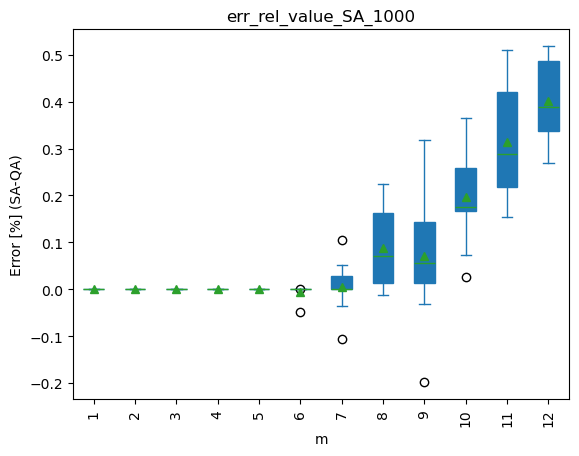

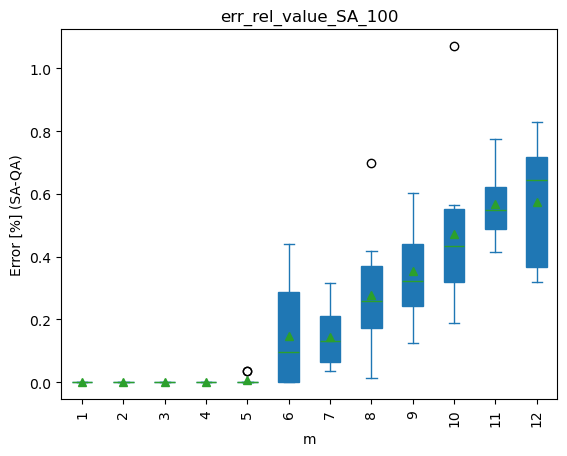

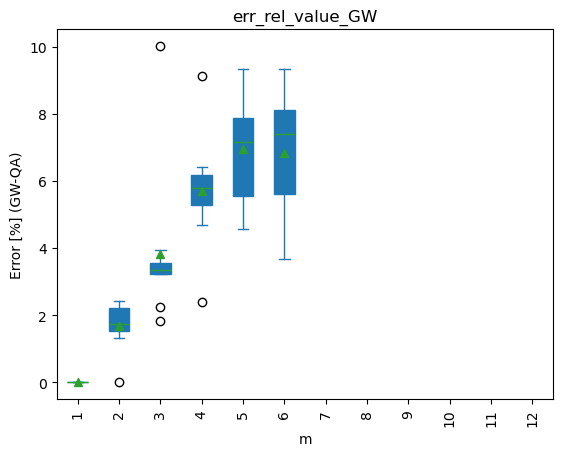

In [7]:
myFig = plt.figure()
ax = J_log_QA.reset_index().plot.box(column='err_rel_value_SA_1000', by=['m'], xlabel='m', ylabel='Error [%] (SA-QA)', logy=False, showmeans=True, patch_artist=True, rot=90)
ax = J_log_QA.reset_index().plot.box(column='err_rel_value_SA_100', by=['m'], xlabel='m', ylabel='Error [%] (SA-QA)', logy=False, showmeans=True, patch_artist=True, rot=90)
ax = J_log_QA.reset_index().plot.box(column='err_rel_value_GW', by=['m'], xlabel='m', ylabel='Error [%] (GW-QA)', logy=False, showmeans=True, patch_artist=True, rot=90)